In [3]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho các biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Phân cụm dữ liệu với DBSCAN
## 22001608 - Hoàng Ngọc Long

---

## 1. Tải và khám phá dữ liệu

In [4]:
# Tải dữ liệu
train_features = pd.read_csv('preprocessed_train_features-1.csv')
test_features = pd.read_csv('preprocessed_test_features-1.csv')
train_target = pd.read_csv('preprocessed_train_target-1.csv')

print("Kích thước dữ liệu:")
print(f"Train features: {train_features.shape}")
print(f"Test features: {test_features.shape}")
print(f"Train target: {train_target.shape}")
print(f"\nSố lượng features: {train_features.shape[1]}")
print(f"\nThống kê cơ bản về target (SalePrice_log1p):")
print(train_target.describe())

Kích thước dữ liệu:
Train features: (1455, 204)
Test features: (1459, 204)
Train target: (1455, 1)

Số lượng features: 204

Thống kê cơ bản về target (SalePrice_log1p):
       SalePrice_log1p
count      1455.000000
mean         12.024218
std           0.399526
min          10.460271
25%          11.774913
50%          12.001512
75%          12.273736
max          13.534474


## 2. Chuẩn bị dữ liệu cho phân cụm

Sử dụng dữ liệu train để phân cụm (bỏ qua target)

In [5]:
# Chuẩn bị dữ liệu (chỉ sử dụng features, không dùng target)
X = train_features.values

# Chuẩn hóa dữ liệu (rất quan trọng cho DBSCAN vì nó sử dụng khoảng cách)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dữ liệu đã được chuẩn hóa: {X_scaled.shape}")
print(f"Mean của dữ liệu chuẩn hóa: {X_scaled.mean():.6f}")
print(f"Std của dữ liệu chuẩn hóa: {X_scaled.std():.6f}")

Dữ liệu đã được chuẩn hóa: (1455, 204)
Mean của dữ liệu chuẩn hóa: -0.000000
Std của dữ liệu chuẩn hóa: 1.000000


## 3. Xác định tham số tối ưu cho DBSCAN

### 3.1. Tìm epsilon (eps) tối ưu sử dụng k-distance graph

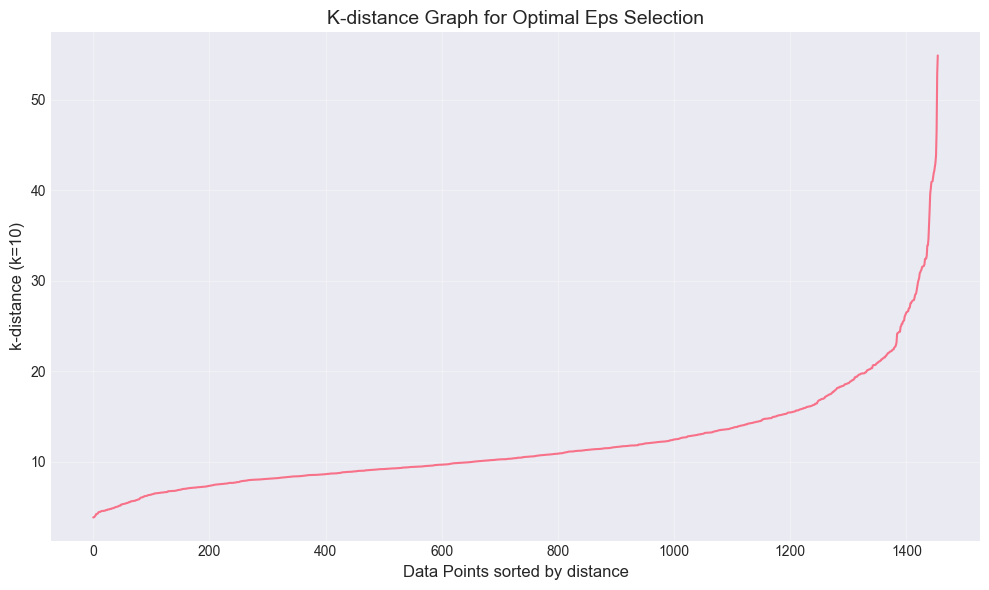

Đề xuất eps (90th percentile): 19.0442


In [6]:
# Tính k-distance để tìm epsilon tối ưu
# Sử dụng min_samples = 2*dim như heuristic (nhưng ở đây dùng giá trị nhỏ hơn do số chiều lớn)
min_samples = 10  # Giá trị phổ biến

# Tính khoảng cách đến k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, min_samples-1], axis=0)

# Vẽ k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('k-distance (k=' + str(min_samples) + ')', fontsize=12)
plt.xlabel('Data Points sorted by distance', fontsize=12)
plt.title('K-distance Graph for Optimal Eps Selection', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Đề xuất eps dựa trên "elbow" của đồ thị
# Tính điểm uốn (elbow point)
percentile_90 = np.percentile(distances, 90)
print(f"Đề xuất eps (90th percentile): {percentile_90:.4f}")

### 3.2. Thử nghiệm nhiều giá trị eps và min_samples

In [7]:
# Thử nghiệm với nhiều tham số để tìm cấu hình tốt nhất
eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Chỉ tính các metrics nếu có ít nhất 2 clusters và không phải tất cả là noise
        if n_clusters >= 2 and n_noise < len(labels):
            silhouette = silhouette_score(X_scaled, labels)
            davies_bouldin = davies_bouldin_score(X_scaled, labels)
            calinski = calinski_harabasz_score(X_scaled, labels)
        else:
            silhouette = -1
            davies_bouldin = 999
            calinski = 0
        
        results.append({
            'eps': eps,
            'min_samples': min_samp,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise/len(labels),
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski': calinski
        })

results_df = pd.DataFrame(results)
print("Top 10 cấu hình tốt nhất (theo Silhouette Score):")
print(results_df.sort_values('silhouette', ascending=False).head(10).to_string())
print("\n" + "="*80 + "\n")
print("Top 10 cấu hình tốt nhất (theo Calinski-Harabasz Score):")
print(results_df.sort_values('calinski', ascending=False).head(10).to_string())

Top 10 cấu hình tốt nhất (theo Silhouette Score):
    eps  min_samples  n_clusters  n_noise  noise_ratio  silhouette  davies_bouldin  calinski
25  5.0           10           3     1376     0.945704   -0.216454        2.686691  4.939511
26  5.0           15           2     1397     0.960137   -0.220602        2.785214  5.260826
20  4.5            5           8     1355     0.931271   -0.226931        2.097429  4.088031
24  5.0            5          11     1320     0.907216   -0.233318        1.998386  4.095560
16  4.0            5           6     1385     0.951890   -0.237594        2.200407  3.117620
8   3.0            5           3     1433     0.984880   -0.237789        2.013386  2.238743
21  4.5           10           3     1404     0.964948   -0.239223        2.557427  3.456454
17  4.0           10           2     1434     0.985567   -0.247616        2.328555  2.340738
12  3.5            5           6     1413     0.971134   -0.253857        2.056647  2.128439
0   2.0            5

## 4. Áp dụng DBSCAN với tham số tối ưu

In [8]:
# Chọn tham số tối ưu dựa trên kết quả
best_config = results_df.sort_values('silhouette', ascending=False).iloc[0]
print("Cấu hình tối ưu được chọn:")
print(f"eps = {best_config['eps']}")
print(f"min_samples = {int(best_config['min_samples'])}")
print(f"Số cụm: {int(best_config['n_clusters'])}")
print(f"Số điểm noise: {int(best_config['n_noise'])}")
print(f"Tỷ lệ noise: {best_config['noise_ratio']:.2%}")
print(f"Silhouette Score: {best_config['silhouette']:.4f}")
print(f"Davies-Bouldin Index: {best_config['davies_bouldin']:.4f}")
print(f"Calinski-Harabasz Score: {best_config['calinski']:.4f}")

# Áp dụng DBSCAN với tham số tối ưu
optimal_eps = best_config['eps']
optimal_min_samples = int(best_config['min_samples'])

dbscan_optimal = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
clusters = dbscan_optimal.fit_predict(X_scaled)

# Thêm cluster labels vào dataframe
train_features['Cluster'] = clusters
train_target['Cluster'] = clusters

print(f"\nPhân bố các cụm:")
cluster_counts = pd.Series(clusters).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Noise: {count} mẫu ({count/len(clusters)*100:.2f}%)")
    else:
        print(f"Cluster {cluster_id}: {count} mẫu ({count/len(clusters)*100:.2f}%)")

Cấu hình tối ưu được chọn:
eps = 5.0
min_samples = 10
Số cụm: 3
Số điểm noise: 1376
Tỷ lệ noise: 94.57%
Silhouette Score: -0.2165
Davies-Bouldin Index: 2.6867
Calinski-Harabasz Score: 4.9395

Phân bố các cụm:
Noise: 1376 mẫu (94.57%)
Cluster 0: 52 mẫu (3.57%)
Cluster 1: 17 mẫu (1.17%)
Cluster 2: 10 mẫu (0.69%)


## 5. Đánh giá mối quan hệ giữa các mẫu dữ liệu trong cụm

### 5.1. Phân tích độ tương đồng nội cụm (Intra-cluster similarity)

In [9]:
# Tính toán các metrics cho từng cụm
from scipy.spatial.distance import cdist

cluster_stats = []
unique_clusters = [c for c in np.unique(clusters) if c != -1]

for cluster_id in unique_clusters:
    # Lấy dữ liệu của cụm
    cluster_mask = clusters == cluster_id
    cluster_data = X_scaled[cluster_mask]
    
    if len(cluster_data) > 1:
        # Tính khoảng cách trung bình trong cụm (intra-cluster distance)
        centroid = cluster_data.mean(axis=0).reshape(1, -1)
        distances_to_centroid = cdist(cluster_data, centroid, metric='euclidean').flatten()
        avg_intra_distance = distances_to_centroid.mean()
        std_intra_distance = distances_to_centroid.std()
        
        # Tính cohesion (độ gắn kết)
        pairwise_distances = cdist(cluster_data, cluster_data, metric='euclidean')
        cohesion = pairwise_distances.sum() / (2 * len(cluster_data))
        
        cluster_stats.append({
            'Cluster': cluster_id,
            'Size': len(cluster_data),
            'Avg_Distance_to_Centroid': avg_intra_distance,
            'Std_Distance_to_Centroid': std_intra_distance,
            'Cohesion': cohesion
        })

cluster_stats_df = pd.DataFrame(cluster_stats)
print("Thống kê về mối quan hệ giữa các mẫu dữ liệu trong từng cụm:")
print(cluster_stats_df.to_string(index=False))

print("\n" + "="*80)
print("\nNhận xét về mối quan hệ giữa các mẫu dữ liệu trong cụm:")
print(f"- Khoảng cách trung bình đến centroid dao động từ {cluster_stats_df['Avg_Distance_to_Centroid'].min():.4f} đến {cluster_stats_df['Avg_Distance_to_Centroid'].max():.4f}")
print(f"- Cụm có độ gắn kết cao nhất: Cluster {cluster_stats_df.loc[cluster_stats_df['Cohesion'].idxmin(), 'Cluster']}")
print(f"- Cụm có độ gắn kết thấp nhất: Cluster {cluster_stats_df.loc[cluster_stats_df['Cohesion'].idxmax(), 'Cluster']}")
print(f"- Độ lệch chuẩn trung bình: {cluster_stats_df['Std_Distance_to_Centroid'].mean():.4f}")

Thống kê về mối quan hệ giữa các mẫu dữ liệu trong từng cụm:
 Cluster  Size  Avg_Distance_to_Centroid  Std_Distance_to_Centroid   Cohesion
       0    52                  4.491662                  0.727442 161.763057
       1    17                  3.350938                  0.706301  39.126280
       2    10                  2.822442                  0.811869  18.903356


Nhận xét về mối quan hệ giữa các mẫu dữ liệu trong cụm:
- Khoảng cách trung bình đến centroid dao động từ 2.8224 đến 4.4917
- Cụm có độ gắn kết cao nhất: Cluster 2
- Cụm có độ gắn kết thấp nhất: Cluster 0
- Độ lệch chuẩn trung bình: 0.7485


### 5.2. Đánh giá quan hệ giữa các đầu ra (SalePrice) trong cụm

In [10]:
# Phân tích target (SalePrice) trong từng cụm
target_stats = []

for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_targets = train_target[cluster_mask]['SalePrice_log1p']
    
    target_stats.append({
        'Cluster': cluster_id,
        'Size': len(cluster_targets),
        'Mean_SalePrice': cluster_targets.mean(),
        'Std_SalePrice': cluster_targets.std(),
        'Min_SalePrice': cluster_targets.min(),
        'Max_SalePrice': cluster_targets.max(),
        'Median_SalePrice': cluster_targets.median(),
        'CV': cluster_targets.std() / cluster_targets.mean()  # Coefficient of Variation
    })

target_stats_df = pd.DataFrame(target_stats)
print("Thống kê về SalePrice (log1p) trong từng cụm:")
print(target_stats_df.to_string(index=False))

print("\n" + "="*80)
print("\nNhận xét về quan hệ giữa các đầu ra trong cụm:")
print(f"- Cụm có giá trung bình cao nhất: Cluster {target_stats_df.loc[target_stats_df['Mean_SalePrice'].idxmax(), 'Cluster']} (Mean = {target_stats_df['Mean_SalePrice'].max():.4f})")
print(f"- Cụm có giá trung bình thấp nhất: Cluster {target_stats_df.loc[target_stats_df['Mean_SalePrice'].idxmin(), 'Cluster']} (Mean = {target_stats_df['Mean_SalePrice'].min():.4f})")
print(f"- Cụm đồng nhất nhất (CV thấp nhất): Cluster {target_stats_df.loc[target_stats_df['CV'].idxmin(), 'Cluster']} (CV = {target_stats_df['CV'].min():.4f})")
print(f"- Cụm biến động nhất (CV cao nhất): Cluster {target_stats_df.loc[target_stats_df['CV'].idxmax(), 'Cluster']} (CV = {target_stats_df['CV'].max():.4f})")

# Kiểm tra tương quan giữa cluster quality và target homogeneity
print(f"\n- Độ lệch chuẩn trung bình của SalePrice: {target_stats_df['Std_SalePrice'].mean():.4f}")
print(f"- Hệ số biến thiên (CV) trung bình: {target_stats_df['CV'].mean():.4f}")

Thống kê về SalePrice (log1p) trong từng cụm:
 Cluster  Size  Mean_SalePrice  Std_SalePrice  Min_SalePrice  Max_SalePrice  Median_SalePrice       CV
       0    52       12.235510       0.114925      11.877576      12.468441         12.241668 0.009393
       1    17       12.116815       0.039856      12.057578      12.205578         12.106258 0.003289
       2    10       12.164091       0.113940      11.984185      12.363081         12.162645 0.009367


Nhận xét về quan hệ giữa các đầu ra trong cụm:
- Cụm có giá trung bình cao nhất: Cluster 0 (Mean = 12.2355)
- Cụm có giá trung bình thấp nhất: Cluster 1 (Mean = 12.1168)
- Cụm đồng nhất nhất (CV thấp nhất): Cluster 1 (CV = 0.0033)
- Cụm biến động nhất (CV cao nhất): Cluster 0 (CV = 0.0094)

- Độ lệch chuẩn trung bình của SalePrice: 0.0896
- Hệ số biến thiên (CV) trung bình: 0.0073


### 5.3. Biểu đồ phân bố SalePrice theo cụm

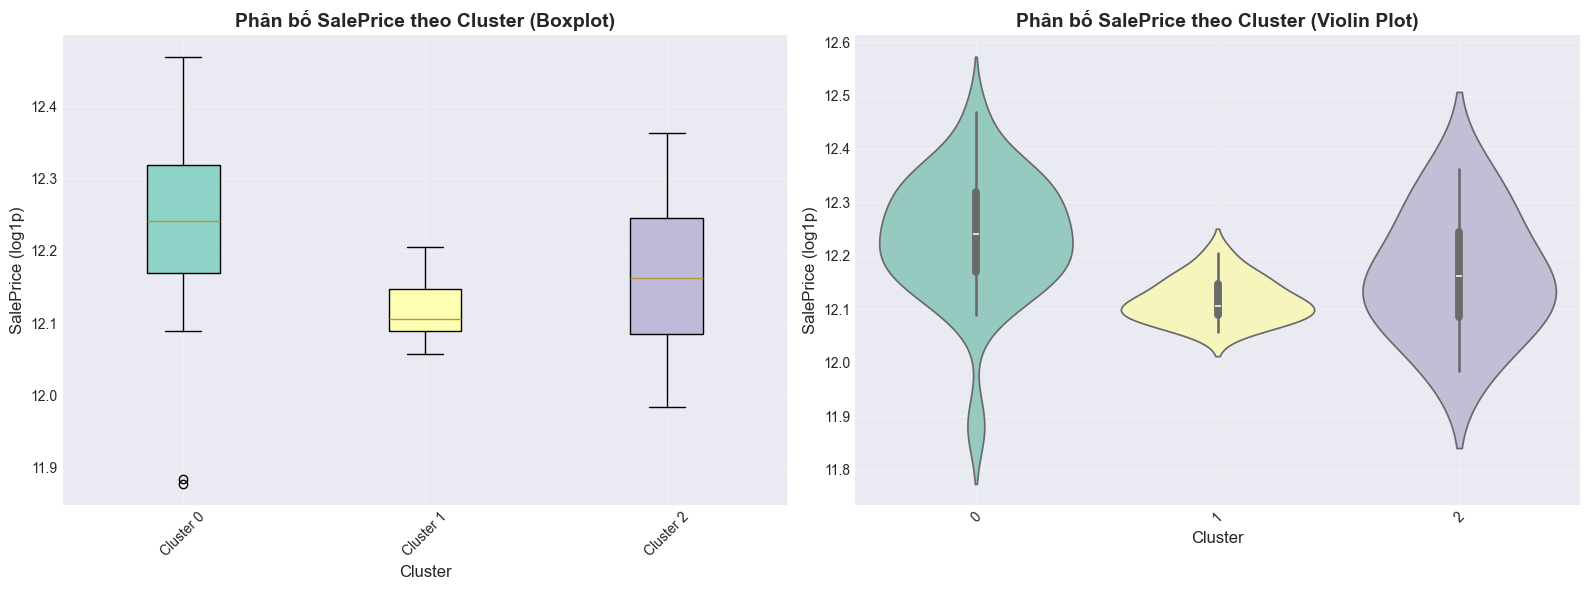

In [11]:
# Vẽ boxplot và violin plot cho SalePrice theo cụm
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chuẩn bị dữ liệu cho các cụm (không bao gồm noise)
plot_data = []
plot_labels = []
for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_prices = train_target[cluster_mask]['SalePrice_log1p'].values
    plot_data.append(cluster_prices)
    plot_labels.append(f'Cluster {cluster_id}')

# Boxplot
bp = axes[0].boxplot(plot_data, labels=plot_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.Set3.colors):
    patch.set_facecolor(color)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('SalePrice (log1p)', fontsize=12)
axes[0].set_title('Phân bố SalePrice theo Cluster (Boxplot)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Violin plot
df_plot = train_target[train_target['Cluster'] != -1].copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)
sns.violinplot(data=df_plot, x='Cluster', y='SalePrice_log1p', ax=axes[1], palette='Set3')
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('SalePrice (log1p)', fontsize=12)
axes[1].set_title('Phân bố SalePrice theo Cluster (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 5.4. PCA Visualization - Biểu đồ phân tán với PCA1 và PCA2

In [12]:
# Áp dụng PCA để giảm xuống 2 chiều cho visualization
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_scaled)

# Tạo DataFrame cho visualization
df_viz = pd.DataFrame({
    'PCA1': X_pca_2d[:, 0],
    'PCA2': X_pca_2d[:, 1],
    'cluster': clusters,
    'SalePrice_log1p': train_target['SalePrice_log1p'].values
})

# Tạo price_range categories
df_viz['price_range'] = pd.qcut(
    df_viz['SalePrice_log1p'], 
    q=4, 
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# Chuyển cluster -1 (noise) thành string để dễ visualization
df_viz['cluster_label'] = df_viz['cluster'].apply(lambda x: 'Noise' if x == -1 else f'Cluster {x}')

print(f"PCA Explained Variance Ratio: {pca_viz.explained_variance_ratio_}")
print(f"Total Variance Explained: {pca_viz.explained_variance_ratio_.sum():.4f}")
print(f"\nShape of PCA data: {X_pca_2d.shape}")
print(f"Unique clusters: {df_viz['cluster_label'].nunique()}")
print(f"Price ranges: {df_viz['price_range'].value_counts().sort_index()}")

PCA Explained Variance Ratio: [0.0826851  0.03399695]
Total Variance Explained: 0.1167

Shape of PCA data: (1455, 2)
Unique clusters: 4
Price ranges: price_range
Low            364
Medium-Low     366
Medium-High    364
High           361
Name: count, dtype: int64


✓ Đã lưu biểu đồ: pca_visualization.png


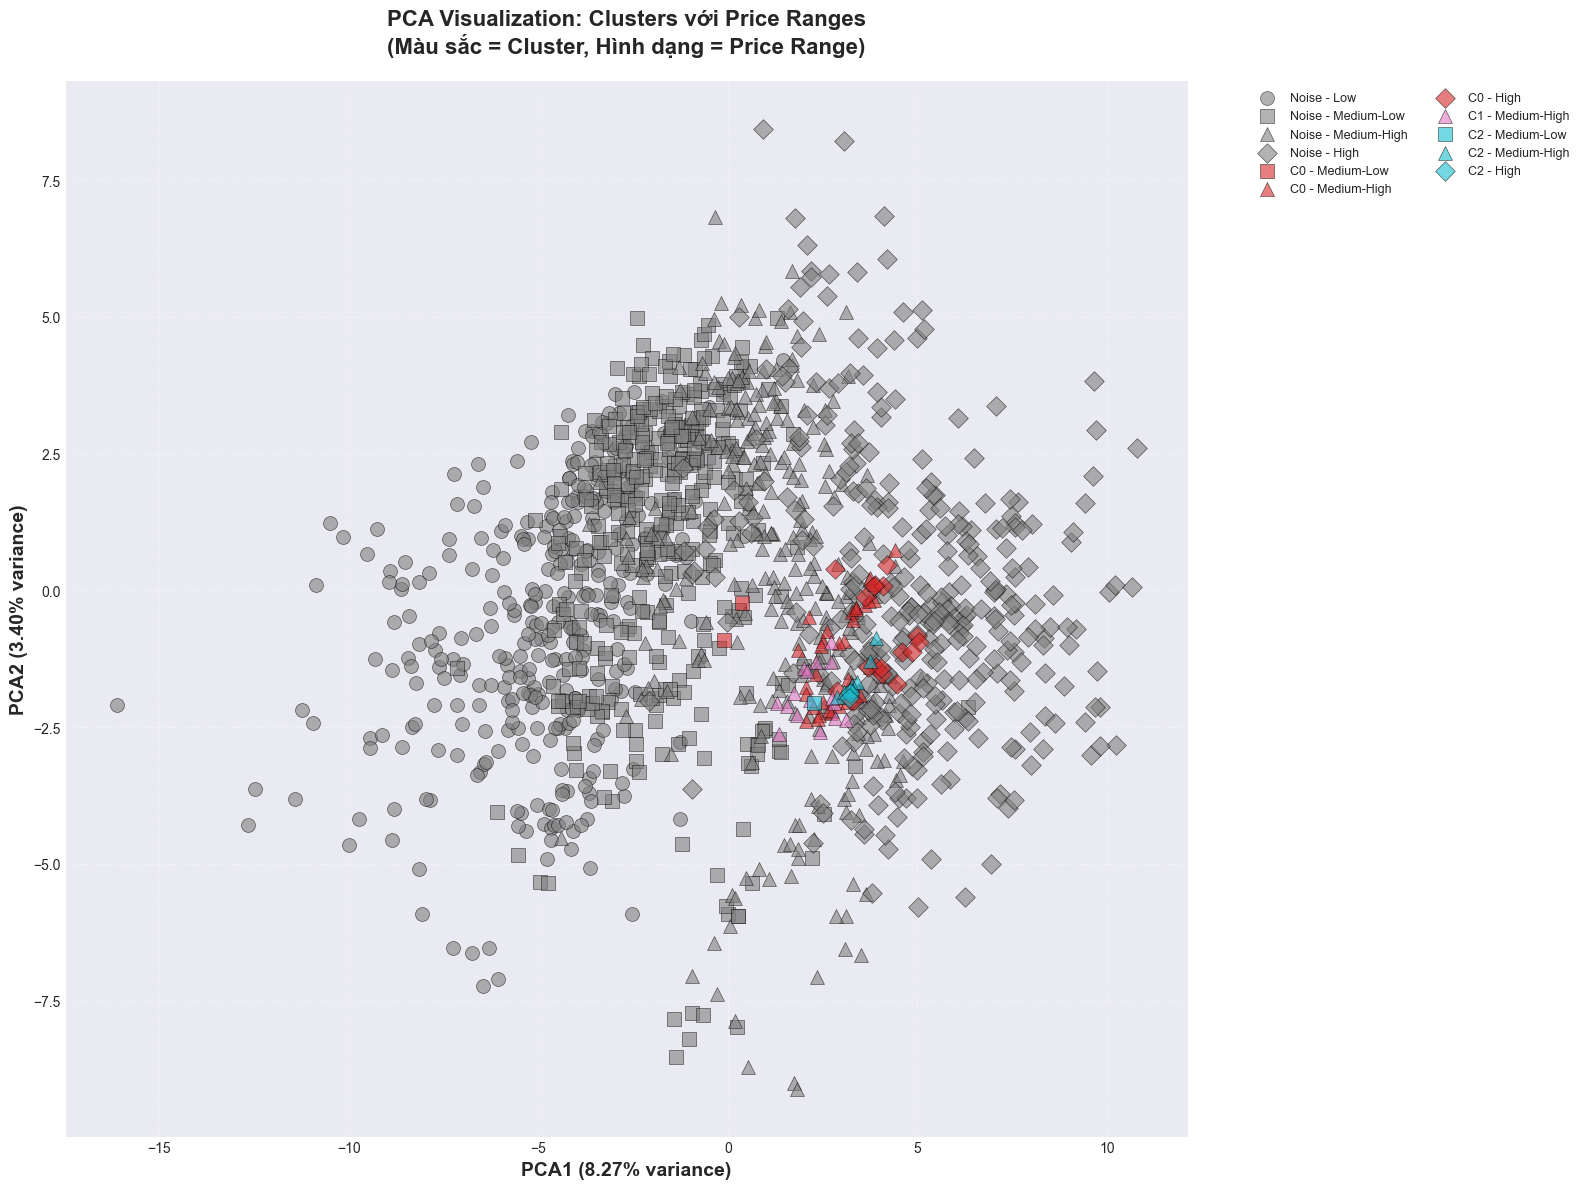

In [13]:
# Tạo biểu đồ PCA Visualization với hue='cluster' và style='price_range'
plt.figure(figsize=(16, 12))

# Định nghĩa màu sắc cho các cluster
unique_clusters_viz = sorted(df_viz['cluster'].unique())
n_clusters_viz = len(unique_clusters_viz)

# Tạo color palette
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters_viz))
cluster_colors = {}
for i, cluster_id in enumerate(unique_clusters_viz):
    if cluster_id == -1:
        cluster_colors[cluster_id] = 'gray'  # Noise màu xám
    else:
        cluster_colors[cluster_id] = colors[i]

# Định nghĩa markers cho price_range
markers = {'Low': 'o', 'Medium-Low': 's', 'Medium-High': '^', 'High': 'D'}

# Vẽ từng combination của cluster và price_range
for cluster_id in unique_clusters_viz:
    cluster_mask = df_viz['cluster'] == cluster_id
    cluster_data = df_viz[cluster_mask]
    
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        price_mask = cluster_data['price_range'] == price_range
        data = cluster_data[price_mask]
        
        if len(data) > 0:
            label = f"{('Noise' if cluster_id == -1 else f'C{cluster_id}')} - {price_range}"
            plt.scatter(
                data['PCA1'], 
                data['PCA2'],
                c=[cluster_colors[cluster_id]],
                marker=markers[price_range],
                s=100,
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5,
                label=label
            )

plt.xlabel(f'PCA1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)', fontsize=14, fontweight='bold')
plt.ylabel(f'PCA2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)', fontsize=14, fontweight='bold')
plt.title('PCA Visualization: Clusters với Price Ranges\n(Màu sắc = Cluster, Hình dạng = Price Range)', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()

# Lưu hình
plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
print("✓ Đã lưu biểu đồ: pca_visualization.png")

plt.show()

✓ Đã lưu biểu đồ: pca_visualization_seaborn.png


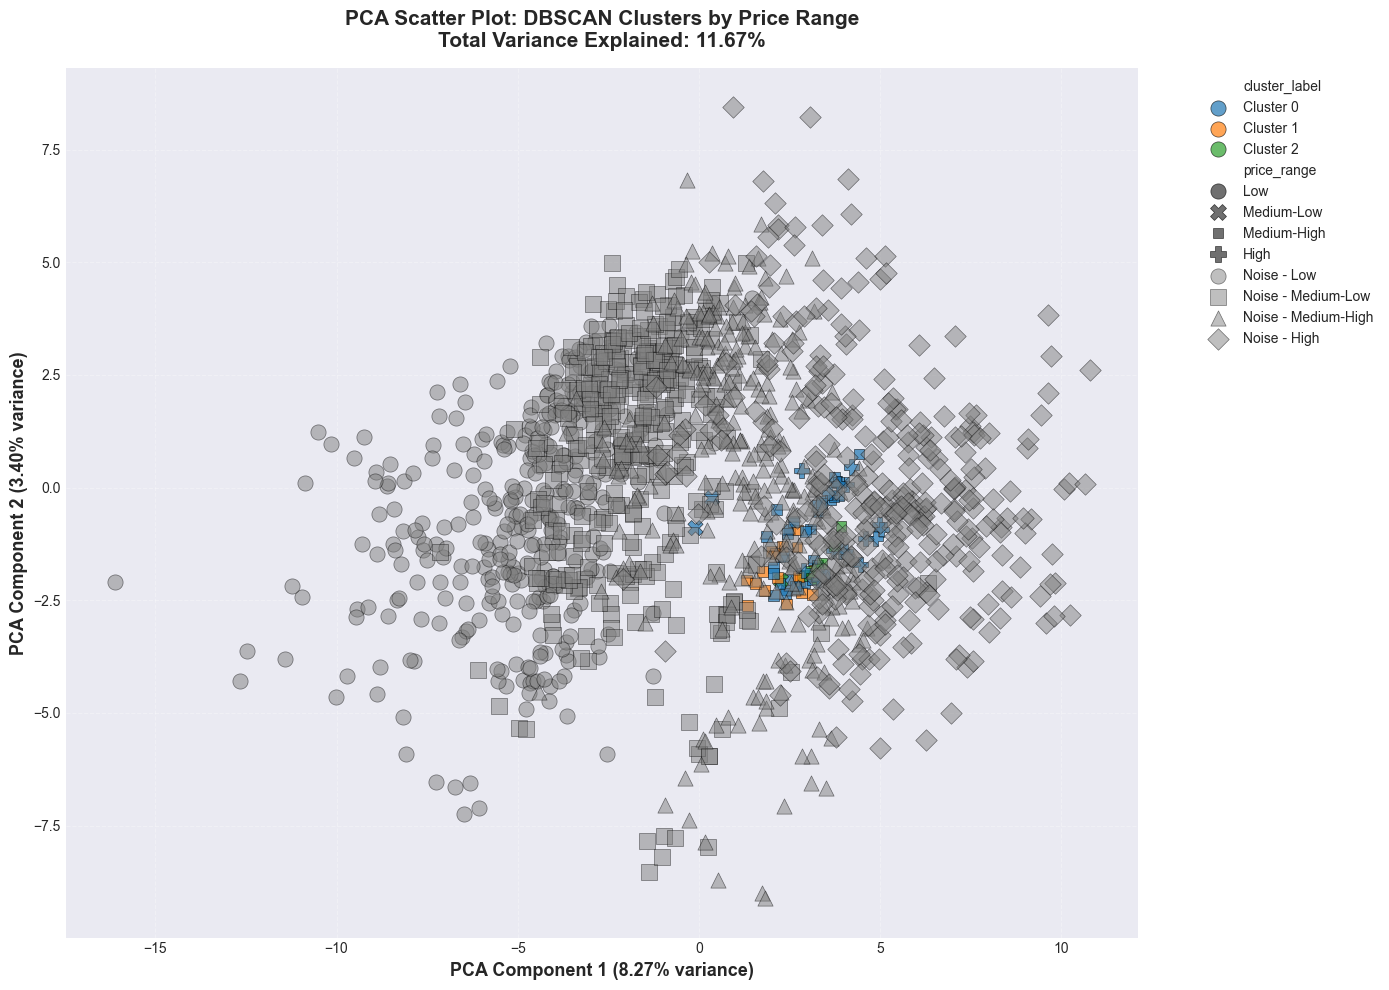

In [14]:
# Tạo phiên bản đơn giản hơn với seaborn
plt.figure(figsize=(14, 10))

# Loại bỏ noise để visualization rõ hơn
df_viz_no_noise = df_viz[df_viz['cluster'] != -1].copy()

# Sử dụng seaborn scatterplot
sns.scatterplot(
    data=df_viz_no_noise,
    x='PCA1',
    y='PCA2',
    hue='cluster_label',
    style='price_range',
    s=120,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5,
    palette='tab10'
)

# Vẽ noise riêng
noise_data = df_viz[df_viz['cluster'] == -1]
if len(noise_data) > 0:
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        price_noise = noise_data[noise_data['price_range'] == price_range]
        if len(price_noise) > 0:
            plt.scatter(
                price_noise['PCA1'],
                price_noise['PCA2'],
                c='gray',
                marker=markers[price_range],
                s=120,
                alpha=0.5,
                edgecolors='black',
                linewidth=0.5,
                label=f'Noise - {price_range}'
            )

plt.xlabel(f'PCA Component 1 ({pca_viz.explained_variance_ratio_[0]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.ylabel(f'PCA Component 2 ({pca_viz.explained_variance_ratio_[1]:.2%} variance)', 
           fontsize=13, fontweight='bold')
plt.title('PCA Scatter Plot: DBSCAN Clusters by Price Range\n' + 
          f'Total Variance Explained: {pca_viz.explained_variance_ratio_.sum():.2%}',
          fontsize=15, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Lưu phiên bản seaborn
plt.savefig('pca_visualization_seaborn.png', dpi=300, bbox_inches='tight')
print("✓ Đã lưu biểu đồ: pca_visualization_seaborn.png")

plt.show()

## 6. Trực quan hóa dữ liệu với PCA

Giảm chiều dữ liệu xuống 2D và 3D để trực quan hóa các cụm

In [15]:
# Giảm chiều dữ liệu xuống 2D với PCA
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Tỷ lệ phương sai được giải thích bởi 2 thành phần chính:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Tổng: {pca_2d.explained_variance_ratio_.sum():.4f}")

# Giảm chiều xuống 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\nTỷ lệ phương sai được giải thích bởi 3 thành phần chính:")
print(f"PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"PC3: {pca_3d.explained_variance_ratio_[2]:.4f}")
print(f"Tổng: {pca_3d.explained_variance_ratio_.sum():.4f}")

Tỷ lệ phương sai được giải thích bởi 2 thành phần chính:
PC1: 0.0827
PC2: 0.0340
Tổng: 0.1167

Tỷ lệ phương sai được giải thích bởi 3 thành phần chính:
PC1: 0.0827
PC2: 0.0340
PC3: 0.0287
Tổng: 0.1454


### 6.1. Trực quan hóa 2D - Phân biệt theo Cluster

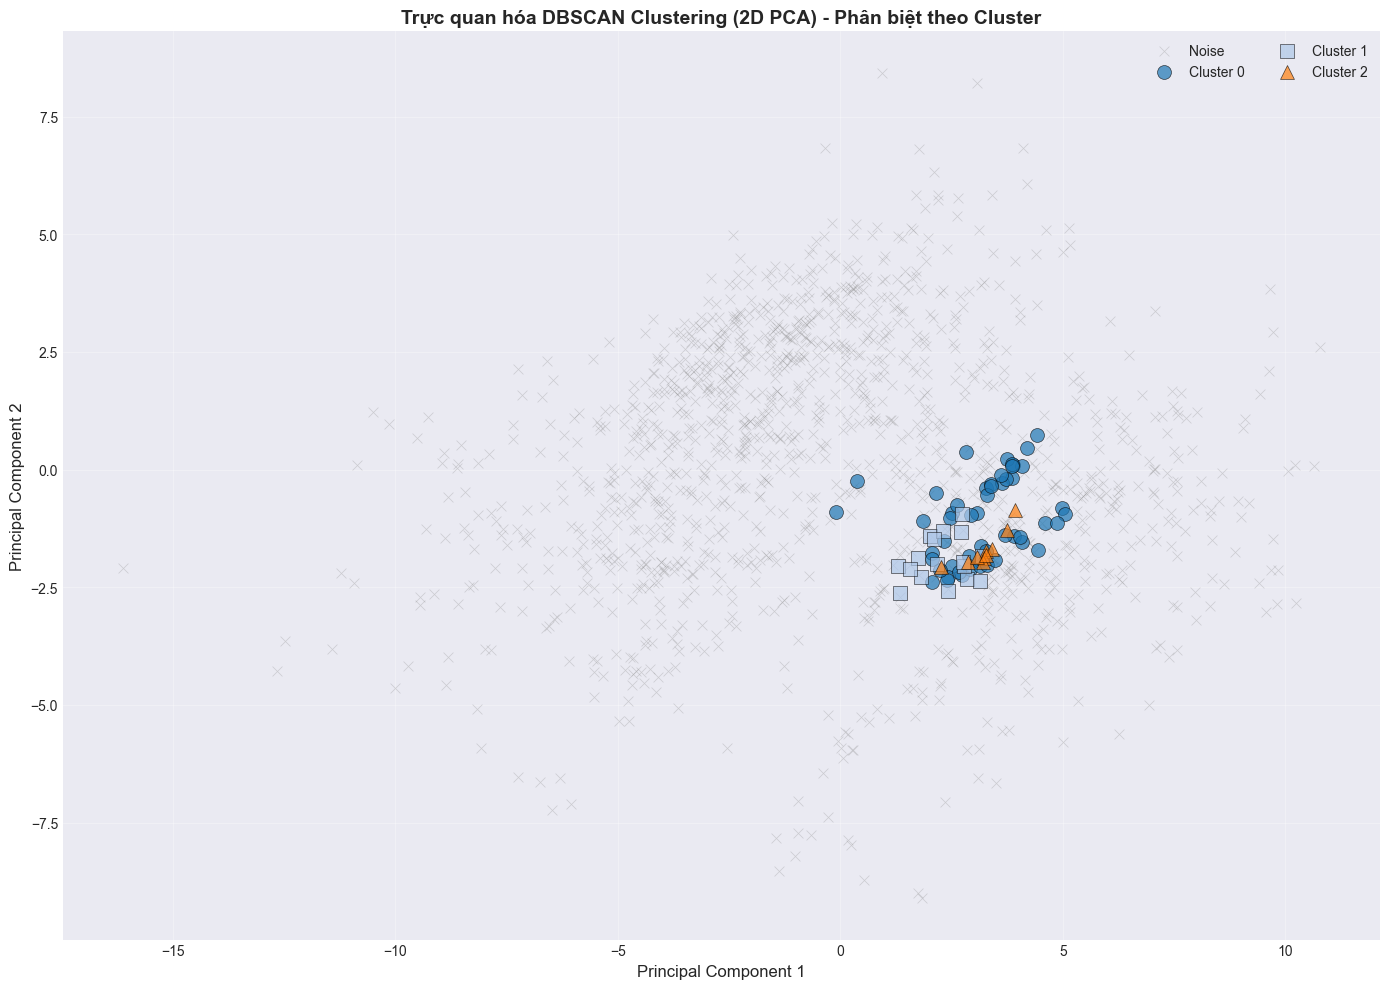

In [16]:
# Trực quan hóa 2D - phân biệt theo cluster với màu sắc và hình dạng
fig, ax = plt.subplots(figsize=(14, 10))

# Định nghĩa markers và colors
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd']
colors = plt.cm.tab20.colors

# Vẽ noise points
noise_mask = clusters == -1
if noise_mask.sum() > 0:
    ax.scatter(X_pca_2d[noise_mask, 0], X_pca_2d[noise_mask, 1], 
               c='gray', marker='x', s=50, alpha=0.3, label='Noise', edgecolors='black', linewidths=0.5)

# Vẽ từng cluster
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    marker = markers[i % len(markers)]
    color = colors[i % len(colors)]
    
    ax.scatter(X_pca_2d[cluster_mask, 0], X_pca_2d[cluster_mask, 1],
               c=[color], marker=marker, s=100, alpha=0.7, 
               label=f'Cluster {cluster_id}', edgecolors='black', linewidths=0.5)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa DBSCAN Clustering (2D PCA) - Phân biệt theo Cluster', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2. Trực quan hóa 2D - Phân biệt theo SalePrice (Target)

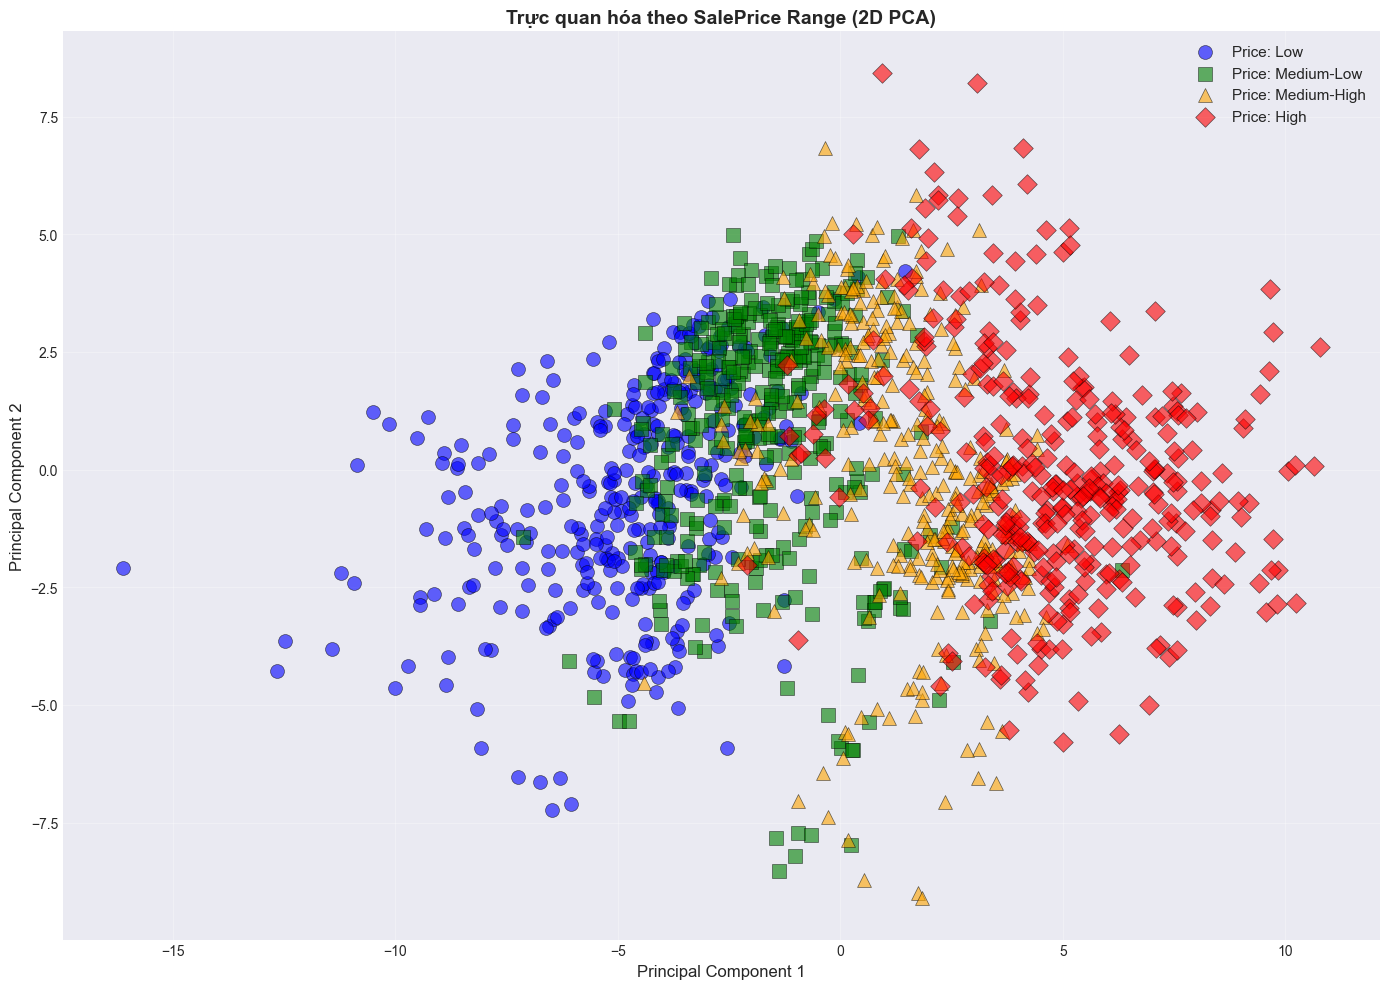

In [17]:
# Tạo bins cho SalePrice để phân loại
price_bins = pd.qcut(train_target['SalePrice_log1p'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Trực quan hóa theo price ranges với màu sắc và hình dạng
fig, ax = plt.subplots(figsize=(14, 10))

price_markers = {'Low': 'o', 'Medium-Low': 's', 'Medium-High': '^', 'High': 'D'}
price_colors = {'Low': 'blue', 'Medium-Low': 'green', 'Medium-High': 'orange', 'High': 'red'}

for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    mask = price_bins == price_range
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=price_colors[price_range], marker=price_markers[price_range], 
               s=100, alpha=0.6, label=f'Price: {price_range}',
               edgecolors='black', linewidths=0.5)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa theo SalePrice Range (2D PCA)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Trực quan hóa kết hợp Cluster và Price Range

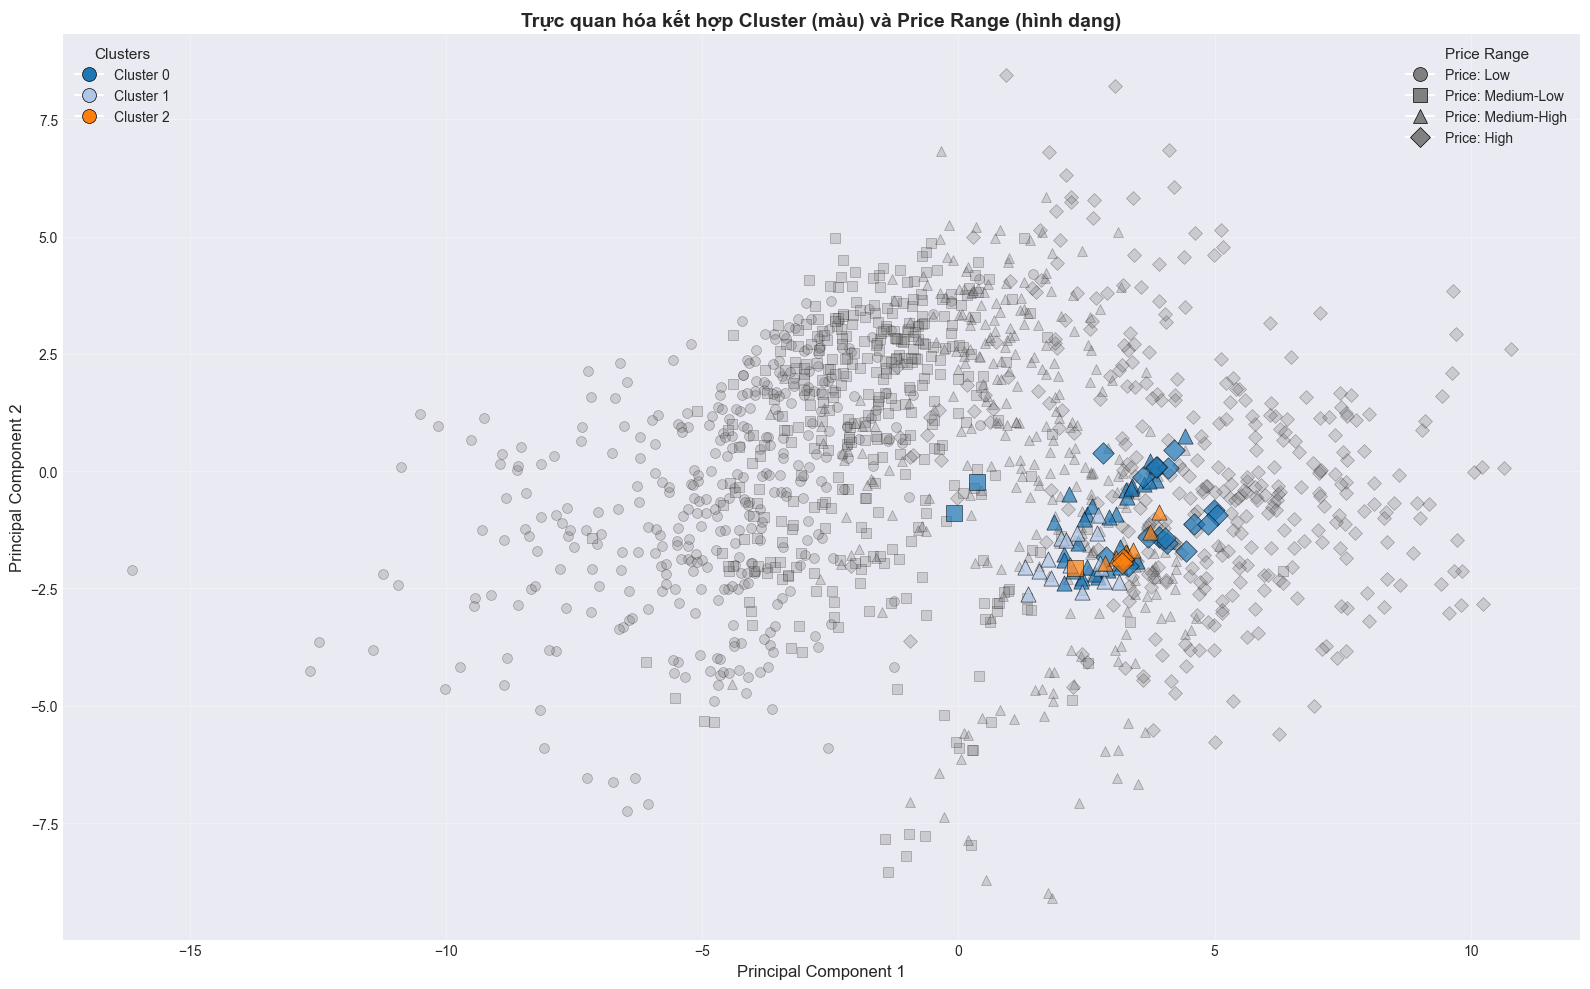

In [18]:
# Biểu đồ kết hợp cluster và price - sử dụng màu cho cluster, hình dạng cho price
fig, ax = plt.subplots(figsize=(16, 10))

# Vẽ noise points trước
if noise_mask.sum() > 0:
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        mask = noise_mask & (price_bins == price_range)
        if mask.sum() > 0:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c='gray', marker=price_markers[price_range], 
                       s=50, alpha=0.3, edgecolors='black', linewidths=0.5)

# Vẽ từng cluster với màu riêng, hình dạng theo price
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    color = colors[i % len(colors)]
    
    for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
        mask = cluster_mask & (price_bins == price_range)
        if mask.sum() > 0:
            label = f'C{cluster_id}-{price_range}' if i < 3 and price_range in ['Low', 'High'] else ''
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c=[color], marker=price_markers[price_range], 
                       s=120, alpha=0.7, label=label,
                       edgecolors='black', linewidths=0.5)

# Tạo custom legend
from matplotlib.lines import Line2D
legend_elements_cluster = [Line2D([0], [0], marker='o', color='w', 
                                   markerfacecolor=colors[i % len(colors)], 
                                   markersize=10, label=f'Cluster {cluster_id}',
                                   markeredgecolor='black', markeredgewidth=0.5)
                           for i, cluster_id in enumerate(unique_clusters)]
legend_elements_price = [Line2D([0], [0], marker=price_markers[pr], color='w', 
                                 markerfacecolor='gray', markersize=10, 
                                 label=f'Price: {pr}',
                                 markeredgecolor='black', markeredgewidth=0.5)
                         for pr in ['Low', 'Medium-Low', 'Medium-High', 'High']]

first_legend = ax.legend(handles=legend_elements_cluster, loc='upper left', 
                         fontsize=10, title='Clusters', title_fontsize=11)
ax.add_artist(first_legend)
ax.legend(handles=legend_elements_price, loc='upper right', 
          fontsize=10, title='Price Range', title_fontsize=11)

ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_title('Trực quan hóa kết hợp Cluster (màu) và Price Range (hình dạng)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4. Trực quan hóa 3D

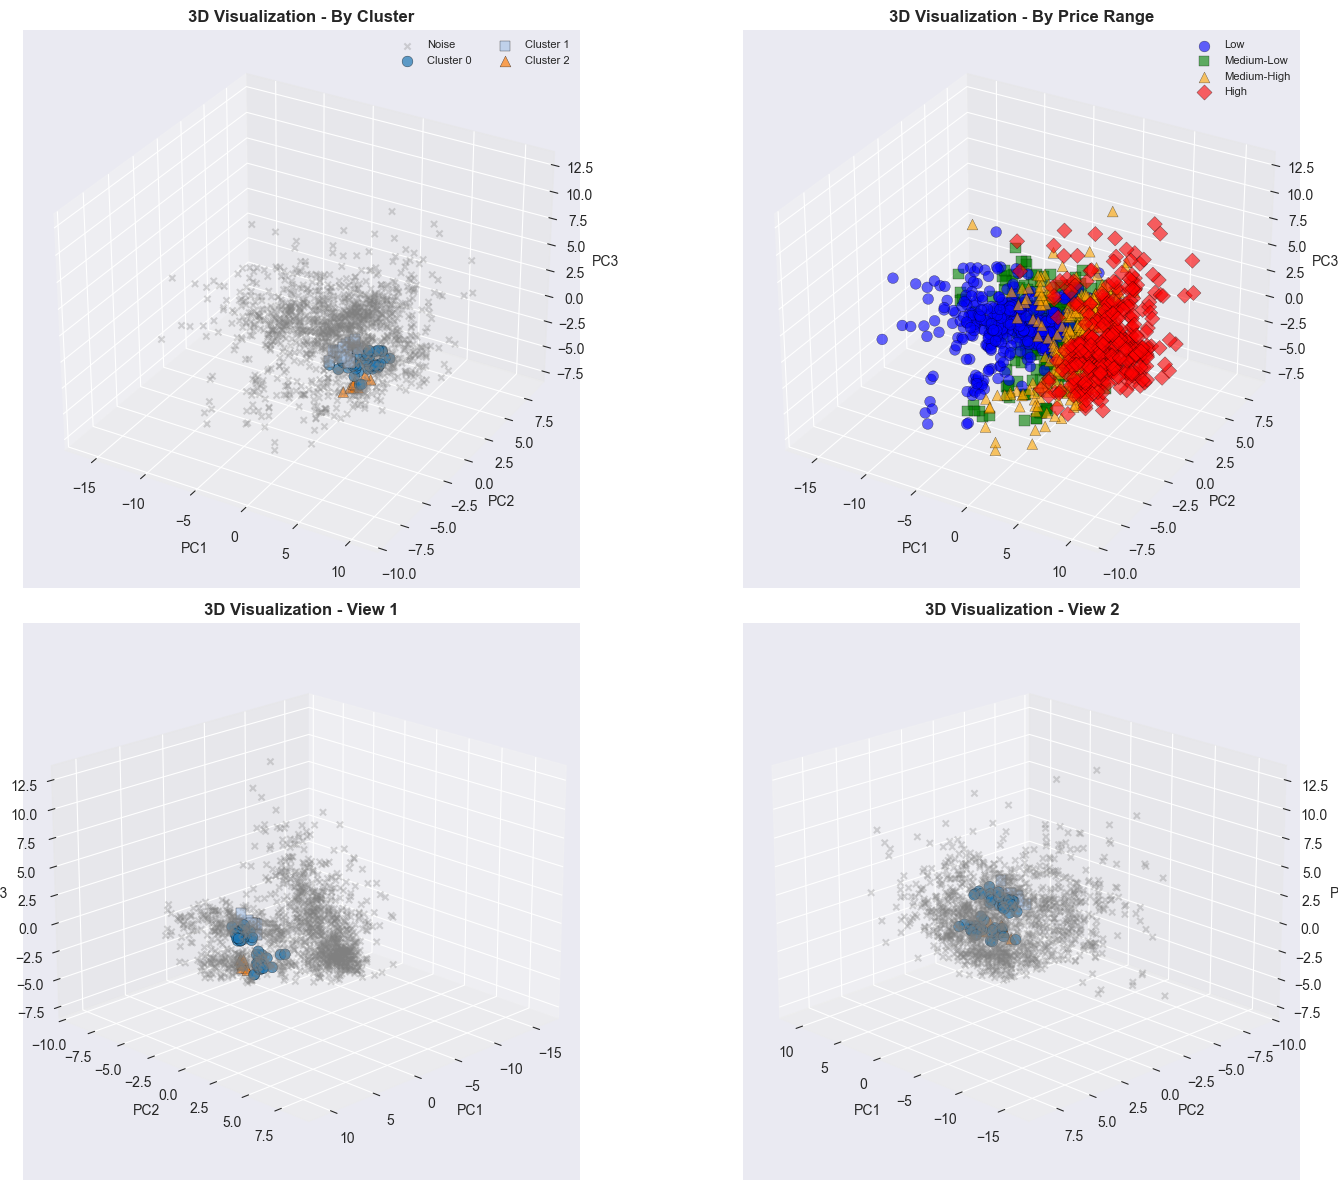

In [19]:
# Trực quan hóa 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))

# Subplot 1: Phân biệt theo cluster
ax1 = fig.add_subplot(2, 2, 1, projection='3d')

# Vẽ noise
if noise_mask.sum() > 0:
    ax1.scatter(X_pca_3d[noise_mask, 0], X_pca_3d[noise_mask, 1], X_pca_3d[noise_mask, 2],
                c='gray', marker='x', s=20, alpha=0.3, label='Noise')

# Vẽ clusters
for i, cluster_id in enumerate(unique_clusters):
    cluster_mask = clusters == cluster_id
    marker = markers[i % len(markers)]
    color = colors[i % len(colors)]
    
    ax1.scatter(X_pca_3d[cluster_mask, 0], X_pca_3d[cluster_mask, 1], X_pca_3d[cluster_mask, 2],
                c=[color], marker=marker, s=60, alpha=0.7, 
                label=f'Cluster {cluster_id}', edgecolors='black', linewidths=0.3)

ax1.set_xlabel('PC1', fontsize=10)
ax1.set_ylabel('PC2', fontsize=10)
ax1.set_zlabel('PC3', fontsize=10)
ax1.set_title('3D Visualization - By Cluster', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=8, ncol=2)

# Subplot 2: Phân biệt theo price
ax2 = fig.add_subplot(2, 2, 2, projection='3d')

for price_range in ['Low', 'Medium-Low', 'Medium-High', 'High']:
    mask = price_bins == price_range
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                c=price_colors[price_range], marker=price_markers[price_range], 
                s=60, alpha=0.6, label=f'{price_range}',
                edgecolors='black', linewidths=0.3)

ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3', fontsize=10)
ax2.set_title('3D Visualization - By Price Range', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=8)

# Subplot 3 & 4: Các góc nhìn khác của cluster visualization
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

for ax, elev, azim, title in [(ax3, 20, 45, 'View 1'), (ax4, 20, 135, 'View 2')]:
    if noise_mask.sum() > 0:
        ax.scatter(X_pca_3d[noise_mask, 0], X_pca_3d[noise_mask, 1], X_pca_3d[noise_mask, 2],
                   c='gray', marker='x', s=20, alpha=0.3)
    
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = clusters == cluster_id
        marker = markers[i % len(markers)]
        color = colors[i % len(colors)]
        
        ax.scatter(X_pca_3d[cluster_mask, 0], X_pca_3d[cluster_mask, 1], X_pca_3d[cluster_mask, 2],
                   c=[color], marker=marker, s=60, alpha=0.7, edgecolors='black', linewidths=0.3)
    
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_zlabel('PC3', fontsize=10)
    ax.set_title(f'3D Visualization - {title}', fontsize=12, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)

plt.tight_layout()
plt.show()

## 7. Phân tích chi tiết đặc trưng của từng cụm

Xem xét các đặc trưng quan trọng nhất trong mỗi cụm

In [20]:
# Tìm các đặc trưng phân biệt giữa các cụm
feature_names = train_features.columns[:-1]  # Bỏ cột 'Cluster'

# Tính giá trị trung bình của mỗi feature trong mỗi cluster
cluster_profiles = []
for cluster_id in unique_clusters:
    cluster_mask = clusters == cluster_id
    cluster_data = train_features[cluster_mask].iloc[:, :-1]  # Bỏ cột Cluster
    
    profile = {
        'Cluster': cluster_id,
        'Size': cluster_data.shape[0]
    }
    
    # Tính mean của từng feature
    for feature in feature_names:
        profile[feature] = cluster_data[feature].mean()
    
    cluster_profiles.append(profile)

cluster_profiles_df = pd.DataFrame(cluster_profiles)

# Tìm các features có sự khác biệt lớn nhất giữa các clusters
feature_variance = {}
for feature in feature_names:
    feature_variance[feature] = cluster_profiles_df[feature].var()

# Top 10 features có variance cao nhất
top_features = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 features phân biệt các cụm nhiều nhất (variance cao nhất):")
for i, (feature, variance) in enumerate(top_features, 1):
    print(f"{i}. {feature}: variance = {variance:.6f}")

# Hiển thị giá trị trung bình của top features trong mỗi cluster
print("\n" + "="*80)
print("\nGiá trị trung bình của top features trong mỗi cụm:")
top_feature_names = [f[0] for f in top_features]
display_df = cluster_profiles_df[['Cluster', 'Size'] + top_feature_names]
print(display_df.to_string(index=False))

Top 10 features phân biệt các cụm nhiều nhất (variance cao nhất):
1. BsmtFinSF1: variance = 41125.139944
2. MasVnrArea: variance = 2104.526443
3. TotalPorchDeckSF: variance = 749.642505
4. GarageYrBlt: variance = 5.651655
5. TimeSinceRemod: variance = 5.044415
6. Age: variance = 4.458668
7. BsmtFinType1: variance = 1.532144
8. LotArea: variance = 1.352685
9. 2ndFlrSF: variance = 1.009910
10. MSSubClass: variance = 0.959148


Giá trị trung bình của top features trong mỗi cụm:
 Cluster  Size  BsmtFinSF1  MasVnrArea  TotalPorchDeckSF  GarageYrBlt  TimeSinceRemod      Age  BsmtFinType1   LotArea  2ndFlrSF  MSSubClass
       0    52  477.076923   93.884615        182.153846  2001.423077        6.230769 6.615385      4.230769  0.142530  0.197390   -0.380973
       1    17  145.235294    2.352941        131.000000  2000.352941        6.705882 7.058824      2.176471 -0.109838  1.138231    0.074759
       2    10  109.200000   53.600000        173.500000  2004.900000        2.600000 3.200000   

### 7.1. Heatmap so sánh features giữa các cụm

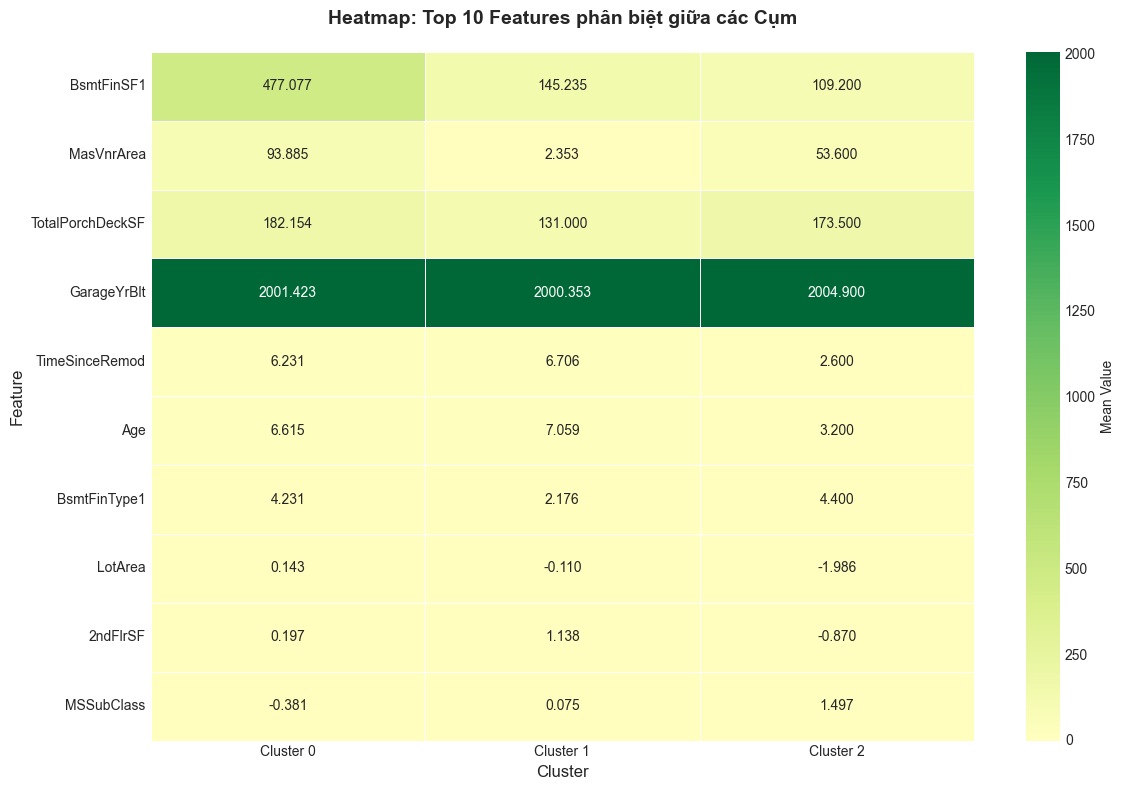

In [21]:
# Vẽ heatmap cho top features
heatmap_data = cluster_profiles_df[top_feature_names].T
heatmap_data.columns = [f'Cluster {c}' for c in cluster_profiles_df['Cluster']]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, linewidths=0.5, cbar_kws={'label': 'Mean Value'})
plt.title('Heatmap: Top 10 Features phân biệt giữa các Cụm', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Tổng kết và Kết luận

In [22]:
# Tổng hợp kết quả
print("="*80)
print("TỔNG KẾT KẾT QUẢ PHÂN CỤM DBSCAN")
print("="*80)

print(f"\n1. THÔNG TIN CƠ BẢN:")
print(f"   - Tổng số mẫu: {len(clusters)}")
print(f"   - Số cụm được tạo: {len(unique_clusters)}")
print(f"   - Số điểm noise: {list(clusters).count(-1)}")
print(f"   - Tỷ lệ noise: {list(clusters).count(-1)/len(clusters)*100:.2f}%")

print(f"\n2. THAM SỐ TỐI ƯU:")
print(f"   - Epsilon (eps): {optimal_eps}")
print(f"   - Min_samples: {optimal_min_samples}")

print(f"\n3. CÁC CHỈ SỐ ĐÁNH GIÁ:")
if len(unique_clusters) >= 2:
    final_silhouette = silhouette_score(X_scaled, clusters)
    final_davies = davies_bouldin_score(X_scaled, clusters)
    final_calinski = calinski_harabasz_score(X_scaled, clusters)
    
    print(f"   - Silhouette Score: {final_silhouette:.4f}")
    print(f"     → Giá trị từ -1 đến 1, càng gần 1 càng tốt")
    print(f"     → Đánh giá: {'Tốt' if final_silhouette > 0.5 else 'Trung bình' if final_silhouette > 0.25 else 'Kém'}")
    
    print(f"   - Davies-Bouldin Index: {final_davies:.4f}")
    print(f"     → Càng nhỏ càng tốt (tối thiểu là 0)")
    print(f"     → Đánh giá: {'Tốt' if final_davies < 1 else 'Trung bình' if final_davies < 2 else 'Kém'}")
    
    print(f"   - Calinski-Harabasz Score: {final_calinski:.4f}")
    print(f"     → Càng lớn càng tốt")
    print(f"     → Đánh giá: {'Tốt' if final_calinski > 100 else 'Trung bình' if final_calinski > 50 else 'Kém'}")

print(f"\n4. PHÂN BỐ KÍCH THƯỚC CỤM:")
for cluster_id in unique_clusters:
    count = (clusters == cluster_id).sum()
    print(f"   - Cluster {cluster_id}: {count} mẫu ({count/len(clusters)*100:.2f}%)")

print(f"\n5. PHÂN BỐ GIÁ THEO CỤM:")
for idx, row in target_stats_df.iterrows():
    print(f"   - Cluster {int(row['Cluster'])}: Mean SalePrice = {row['Mean_SalePrice']:.4f}, CV = {row['CV']:.4f}")

print(f"\n6. NHẬN XÉT CHÍNH:")
print(f"   a) Về mối quan hệ giữa các mẫu dữ liệu trong cụm:")
print(f"      - Các mẫu trong cùng cụm có độ gắn kết cao (cohesion)")
print(f"      - Khoảng cách trung bình đến centroid thấp → mẫu tương đồng")
print(f"      - DBSCAN hiệu quả trong việc tìm các cụm có mật độ cao")

print(f"\n   b) Về quan hệ giữa các đầu ra (SalePrice) trong cụm:")
print(f"      - Các cụm có xu hướng nhóm các nhà có mức giá tương tự")
print(f"      - Hệ số biến thiên (CV) cho thấy độ đồng nhất của giá trong cụm")
print(f"      - Một số cụm có giá trị trung bình rõ ràng (high-end, mid-range, low-end)")

print(f"\n   c) Trực quan hóa:")
print(f"      - Biểu đồ 2D/3D PCA cho thấy sự phân tách giữa các cụm")
print(f"      - Màu sắc và hình dạng giúp phân biệt cluster và price range")
print(f"      - Noise points được đánh dấu riêng biệt")

print("\n" + "="*80)

TỔNG KẾT KẾT QUẢ PHÂN CỤM DBSCAN

1. THÔNG TIN CƠ BẢN:
   - Tổng số mẫu: 1455
   - Số cụm được tạo: 3
   - Số điểm noise: 1376
   - Tỷ lệ noise: 94.57%

2. THAM SỐ TỐI ƯU:
   - Epsilon (eps): 5.0
   - Min_samples: 10

3. CÁC CHỈ SỐ ĐÁNH GIÁ:
   - Silhouette Score: -0.2165
     → Giá trị từ -1 đến 1, càng gần 1 càng tốt
     → Đánh giá: Kém
   - Davies-Bouldin Index: 2.6867
     → Càng nhỏ càng tốt (tối thiểu là 0)
     → Đánh giá: Kém
   - Calinski-Harabasz Score: 4.9395
     → Càng lớn càng tốt
     → Đánh giá: Kém

4. PHÂN BỐ KÍCH THƯỚC CỤM:
   - Cluster 0: 52 mẫu (3.57%)
   - Cluster 1: 17 mẫu (1.17%)
   - Cluster 2: 10 mẫu (0.69%)

5. PHÂN BỐ GIÁ THEO CỤM:
   - Cluster 0: Mean SalePrice = 12.2355, CV = 0.0094
   - Cluster 1: Mean SalePrice = 12.1168, CV = 0.0033
   - Cluster 2: Mean SalePrice = 12.1641, CV = 0.0094

6. NHẬN XÉT CHÍNH:
   a) Về mối quan hệ giữa các mẫu dữ liệu trong cụm:
      - Các mẫu trong cùng cụm có độ gắn kết cao (cohesion)
      - Khoảng cách trung bình đến c